<a href="https://colab.research.google.com/github/TZN209/Grid/blob/master/KmeansImplementation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from __future__ import print_function 
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist
np.random.seed(20)

In [ ]:
#Khởi tạo dữ liệu demo
means = [[2, 2], [9, 3], [3, 6]]
cov = [[1, 0], [0, 1]]
N = 500
X0 = np.random.multivariate_normal(means[0], cov, N)
X1 = np.random.multivariate_normal(means[1], cov, N)
X2 = np.random.multivariate_normal(means[2], cov, N)

X = np.concatenate((X0, X1, X2), axis = 0)
K = 3
original_label = np.asarray([0]*N + [1]*N + [2]*N).T



In [ ]:
def kmeans_display(X, label):
    K = np.amax(label) + 1
    X0 = X[label == 0, :]
    X1 = X[label == 1, :]
    X2 = X[label == 2, :]
    
    plt.plot(X0[:, 0], X0[:, 1], 'b^', markersize = 4, alpha = .8)
    plt.plot(X1[:, 0], X1[:, 1], 'go', markersize = 4, alpha = .8)
    plt.plot(X2[:, 0], X2[:, 1], 'rs', markersize = 4, alpha = .8)

    plt.axis('equal')
    plt.plot()
    plt.show()

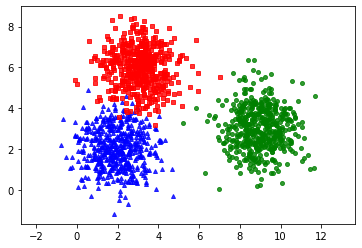

In [ ]:
kmeans_display(X, original_label)

In [ ]:
#Viết hàm khởi tạo điểm trung tâm ngẫu nhiên
def init_centroids(X, k):
  #Lấy ngẫu nhiên k điểm trung tâm trong X
  return X[np.random.choice(X.shape[0], k, replace=False)]

def assign_labels(X, centroids, k):
  clusters = {}
  #Khởi tạo các cluster trống
  for i in range(k):
    clusters[i] = []
  for featureset in X:
    #Tính khoảng cách từ điểm featureset đến từng điểm trung tâm
    distances = [np.linalg.norm(featureset - centroid) for centroid in centroids]
    cluster = distances.index(min(distances))
    clusters[cluster].append(featureset) 
  return clusters

def update_centroids(clusters):
  new_centroids = []
  for cluster, datapoints in clusters.items():
    new_centroids.append(np.average(datapoints, axis=0))
  return new_centroids

def has_converged(centers, new_centers):
  #Hội tụ khi các điểm trung tâm không thay đổi
  return (set([tuple(a) for a in centers]) == set([tuple(a) for a in new_centers]))


In [ ]:
#thuật toán chính
max_iter = 10
centroids = init_centroids(X, K)
for i in range(max_iter):
  #Bước 1: cố định trung tâm, tìm các thuộc gần trung tâm
  clusters = assign_labels(X, centroids, K)
  #Bước 2: Cập nhật trung tâm mới
  new_centroids = update_centroids(clusters)
  #Kiểm tra hội tụ
  if has_converged(centroids, new_centroids):
    print("Converged! at ", i + 1) 
    break
  centroids = new_centroids

Converged! at  6


In [ ]:
#Visualization
X_ = []
labels = []
for cluster, datapoints in clusters.items():
  for datapoint in datapoints:
    X_.append(datapoint)
    labels.append(cluster)



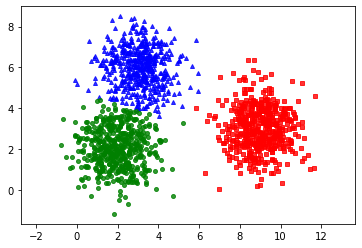

In [ ]:
kmeans_display(np.array(X_), np.array(labels))

In [ ]:
#BTVN: 1. Implement K-means with numpy
#2. K-means++
#3. Random sampling -> POC
